In [112]:
country_to_region_globe = {
    "United Kingdom": "Anglo",
    "Belgium": "Germanic Europe",
    "Ireland": "Anglo",
    "France": "Latin Europe",
    "Germany": "Germanic Europe",
    "Portugal": "Latin Europe",
    "Spain": "Latin Europe",
    "Italy": "Latin Europe",
    "Switzerland": "Latin Europe",
    "Netherlands": "Germanic Europe",
    "Austria": "Germanic Europe",
    "Malta": "Latin Europe",
    "Denmark": "Nordic Europe",
    "Norway": "Nordic Europe",
    "Sweden": "Nordic Europe",
    "Finland": "Nordic Europe",
    "Iceland": "Nordic Europe",
    "Greece": "Eastern Europe",
    "Poland": "Eastern Europe",
    "Czech Republic": "Eastern Europe",
    "Slovakia": "Eastern Europe",
    "Hungary": "Eastern Europe",
    "Romania": "Latin Europe",
    "Belarus": "Eastern Europe",
    "Serbia": "Eastern Europe",
    "Moldova": "Latin Europe",
    "Estonia": "Nordic Europe",
    "Latvia": "Nordic Europe",
    "United States": "Anglo",
    "Canada": "Anglo",
    "Bermuda": "Other",
    "Mexico": "Latin America",
    "Brazil": "Latin America",
    "Chile": "Latin America",
    "Peru": "Latin America",
    "Uruguay": "Latin America",
    "Paraguay": "Latin America",
    "Colombia": "Latin America",
    "Costa Rica": "Latin America",
    "Venezuela": "Latin America",
    "Jamaica": "African",
    "Barbados": "African",
    "Antigua and Barbuda": "African",
    "Saint Lucia": "Other",
    "Kenya": "African",
    "Malawi": "African",
    "South African": "African",
    "Nigeria": "African",
    "Ghana": "African",
    "Senegal": "African",
    "Benin": "African",
    "Madagascar": "African",
    "Ethiopia": "African",
    "Eritrea": "African",
    "Mali": "African",
    "Gambia": "African",
    "United Arab Emirates": "Middle East",
    "Jordan": "Middle East",
    "Syria": "Middle East",
    "Iraq": "Middle East",
    "Lebanon": "Middle East",
    "Egypt": "Middle East",
    "Morocco": "Middle East",
    "Kuwait": "Middle East",
    "Israel": "Latin Europe",
    "Turkey": "Middle East",
    "Afghanistan": "South-East Asia",
    "India": "South-East Asia",
    "Pakistan": "South-East Asia",
    "Bangladesh": "South-East Asia",
    "Sri Lanka": "South-East Asia",
    "Nepal": "South-East Asia",
    "China": "Confucian Asia",
    "Japan": "Confucian Asia",
    "South Korea": "Confucian Asia",
    "Taiwan": "Confucian Asia",
    "Thailand": "South-East Asia",
    "Vietnam": "Confucian Asia",
    "Indonesia": "South-East Asia",
    "Singapore": "Confucian Asia",
    "Brunei": "South-East Asia",
    "Kazakhstan": "Eastern Europe",
    "Kyrgyzstan": "Eastern Europe",
    "Tajikistan": "South-East Asia",
    "Azerbaijan": "Middle East",
    "Georgia": "Eastern Europe",
    "Australia": "Anglo",
    "New Zealand": "Anglo",
    "Samoa": "South-East Asia",
    "Holy See": "Other",
    "South Africa": "African",
    "Philippines": "South-East Asia",
    "Argentina": "Latin America"
}

In [122]:
import glob
import matplotlib.pyplot as plt
import json
import cv2
import numpy as np
import pickle
from collections import defaultdict
import re

SPLIT = 'all'  # one of: 'train', 'test', 'all'
SPLIT_RANGES = {
    'test': (1, 900),
    'train': (901, 2700),
    'all': (1, 2700),
}

path = '../EgoGroups/videos_frames'

files = glob.glob(f'{path}/*')

#print(files)
countries = defaultdict(int)
cities = defaultdict(int)
origin = []


sekai, ours = 0, 0

country_mapping = {
    "USA": "United States",
    "UAE": "United Arab Emirates",
    "Korea": "South Korea",
    "Czechia": "Czech Republic",
    'Türkiye': 'Turkey',
    'México': 'Mexico'
}
#country_mapping['Türkiye'] = 'Turkey'

regions_to_clip_ids = defaultdict(list)
clip_to_region = {}
files.sort()

lo, hi = SPLIT_RANGES[SPLIT]

def clip_num(f):
    return int(f.split('/')[-1].replace('clip_', ''))

files = [f for f in files if lo <= clip_num(f) <= hi]
print(f"SPLIT={SPLIT!r}: {len(files)} clips (clip_{lo:04d}..clip_{hi:04d})")

for file_id, file in enumerate(files):
    
    #print(file)
    path = file.split('/')[-1]
    with open(f'{file.replace('videos_frames','jsons_step1')}.json', 'r') as f:
        data = json.load(f)
    
    country = data['country']
    city = data['city']
    origin.append(data['source'])
    if data['dataset'] == 'sekai':
        sekai+=1
    else:
        ours+=1

    country = re.sub(r'\s*\(.*?\)', '', country).strip()
    if country in country_mapping.keys():
        country = country_mapping[country]

    #print(country_to_region_globe[country])
    regions_to_clip_ids[country_to_region_globe[country]].append(file_id + (180 if file_id > 180 else 0))
    
    cities[data['city']]+=1
    countries[country]+=1
    
    #clip_to_region[path] = country_to_region_globe[country] 
    #print(country_to_region_globe[country])



with open('clip_to_region.pkl','wb') as f:
    pickle.dump(clip_to_region, f)

print('Number of countries:', len(countries))
print('Number of cities:', len(cities))


print(sekai)
print(ours)

print('Sekai (%)', sekai/(sekai+ours))
print('Number of clips (Sekai):', sekai)

print('Ours (%)', ours/(sekai+ours))
print('Number of clips (Ours):', ours)


#print('')
#print('Region to clip IDs:')
#print(regions_to_clip_ids)

SPLIT='all': 2700 clips (clip_0001..clip_2700)
Number of countries: 81
Number of cities: 202
1834
866
Sekai (%) 0.6792592592592592
Number of clips (Sekai): 1834
Ours (%) 0.3207407407407407
Number of clips (Ours): 866


In [123]:
n_clips = len(files)
n_query_clips = n_clips * 5
n_total_images = n_clips * 50  # 50 frames/clip, confirmed via current_total_frames

print(f"SPLIT={SPLIT!r}")
print(f"Number of clips: {n_clips}")
print(f"Number of query clips (clips x5): {n_query_clips}")
print(f"Total images (clips x50 frames/clip): {n_total_images}")

SPLIT='all'
Number of clips: 2700
Number of query clips (clips x5): 13500
Total images (clips x50 frames/clip): 135000


{'United Kingdom': 198, 'Germany': 186, 'United Arab Emirates': 173, 'Japan': 131, 'Italy': 118, 'United States': 108, 'Pakistan': 98, 'Finland': 92, 'China': 82, 'Kenya': 78, 'Jamaica': 74, 'France': 65, 'Czech Republic': 63, 'Chile': 58, 'South Korea': 56, 'Poland': 50, 'Peru': 48, 'Estonia': 48, 'Belarus': 45, 'Norway': 38, 'Mexico': 38, 'Afghanistan': 38, 'Latvia': 36, 'Nigeria': 34, 'Indonesia': 33, 'Portugal': 33, 'Hungary': 33, 'Brazil': 32, 'Nepal': 31, 'Belgium': 31, 'Colombia': 30, 'Ethiopia': 25, 'Iceland': 25, 'Thailand': 24, 'India': 24, 'Austria': 24, 'Turkey': 22, 'Morocco': 22, 'Uruguay': 21, 'Kazakhstan': 21, 'Kuwait': 20, 'Canada': 19, 'Malta': 19, 'Switzerland': 18, 'Venezuela': 16, 'Singapore': 14, 'Greece': 13, 'Sweden': 13, 'Israel': 13, 'Barbados': 12, 'Gambia': 12, 'Kyrgyzstan': 11, 'Egypt': 10, 'Taiwan': 10, 'New Zealand': 9, 'Holy See': 9, 'Georgia': 9, 'South Africa': 9, 'Costa Rica': 8, 'Netherlands': 8, 'Iraq': 6, 'Philippines': 6, 'Azerbaijan': 5, 'Eritrea

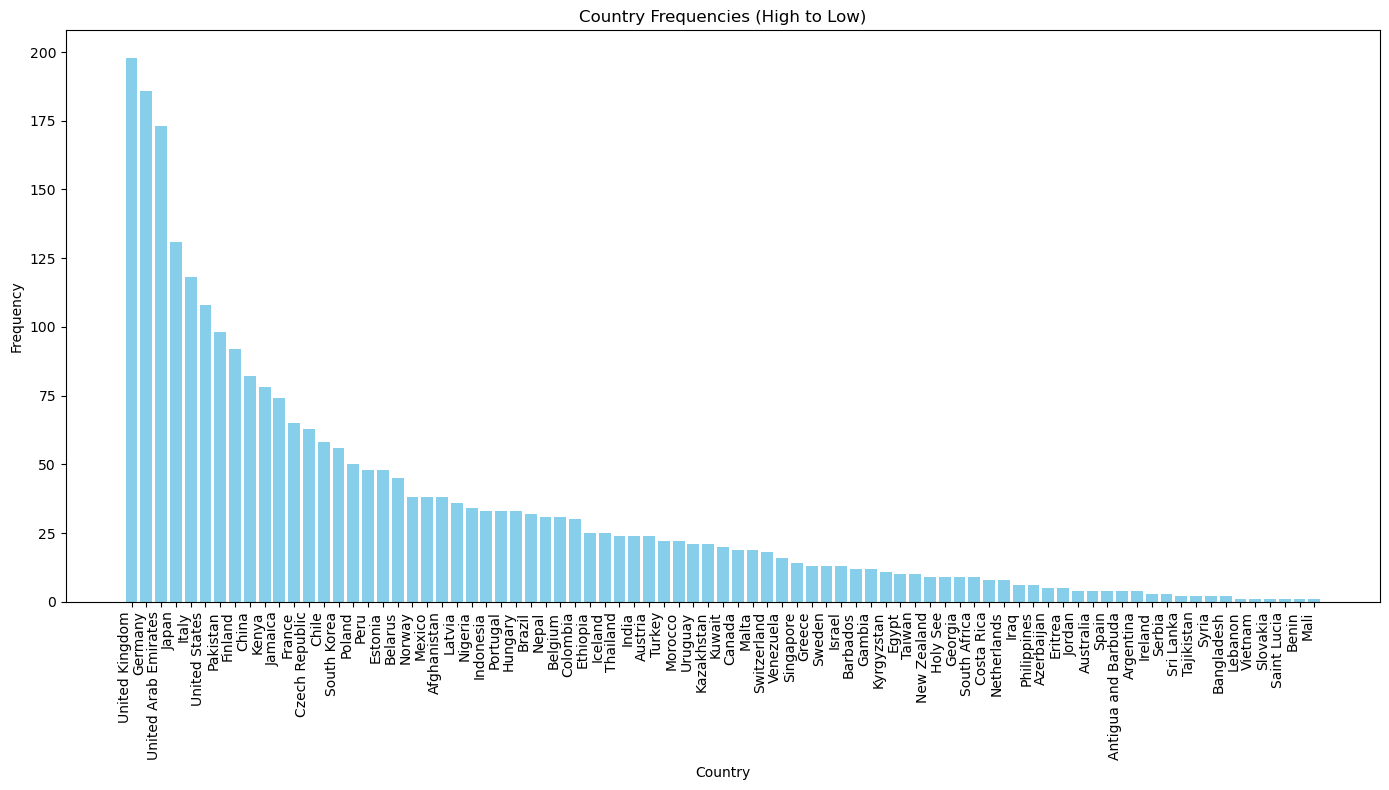

In [115]:
#print(countries)

sorted_data = dict(sorted(countries.items(), key=lambda item: item[1], reverse=True))

print(sorted_data)
# Step 3: Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Frequencies (High to Low)")
plt.tight_layout()
plt.show()

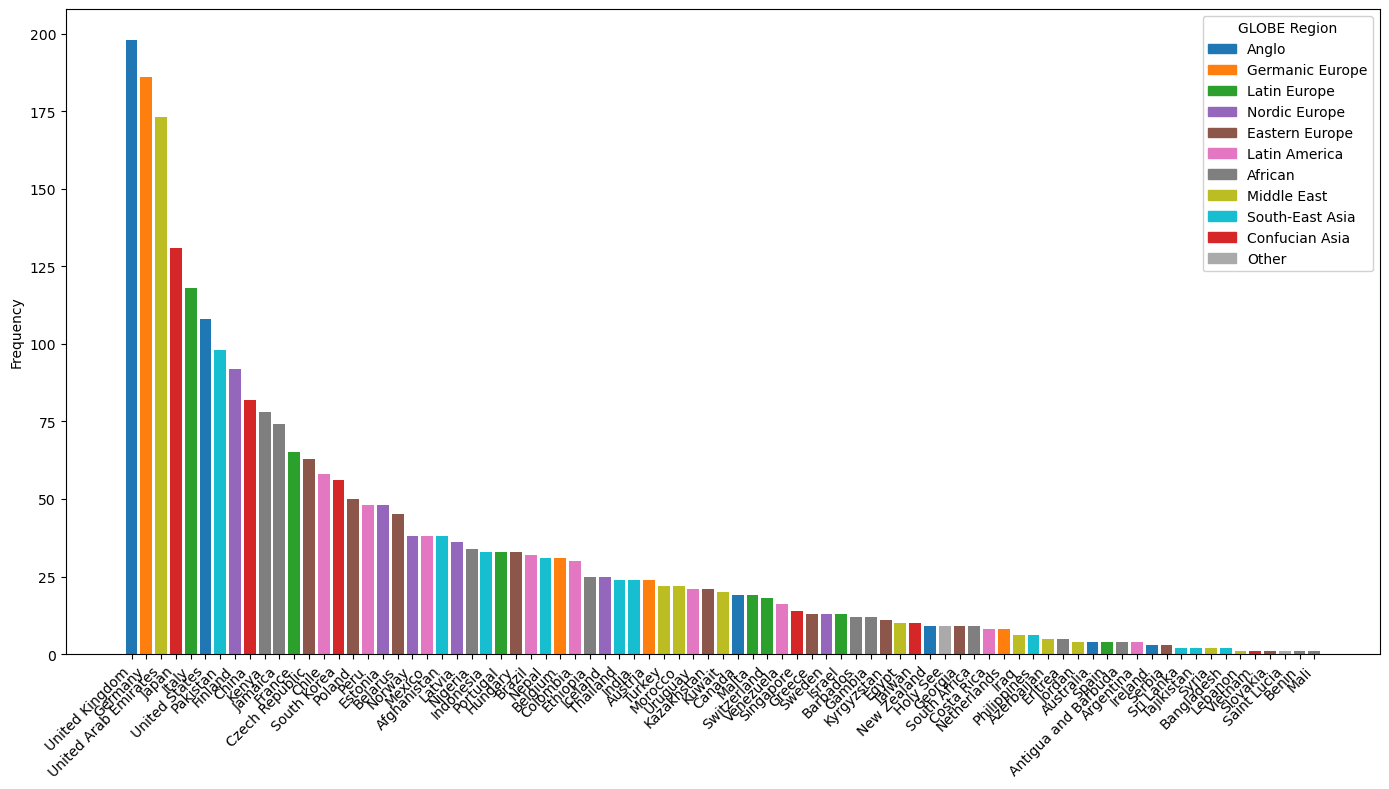

In [116]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Sort countries by frequency
countries = dict(sorted(countries.items(), key=lambda item: item[1], reverse=True))
# Region → color mapping
region_colors = {
    "Anglo": "#1f77b4",
    "Germanic Europe": "#ff7f0e",
    "Latin Europe": "#2ca02c",
    "Nordic Europe": "#9467bd",
    "Eastern Europe": "#8c564b",
    "Latin America": "#e377c2",
    "African": "#7f7f7f",
    "Middle East": "#bcbd22",
    "South-East Asia": "#17becf",
    "Confucian Asia": "#d62728",
    "Other": "#aaaaaa"
}

# Create color list aligned with sorted countries
bar_colors = [
    region_colors.get(country_to_region_globe.get(country, "Other"), "#aaaaaa")
    for country in countries.keys()
]

# Plot
plt.figure(figsize=(14, 8))
plt.bar(countries.keys(), countries.values(), color=bar_colors)

plt.xticks(rotation=45, ha='right')
#plt.xlabel("Country")
plt.ylabel("Frequency")
#plt.title("Country Frequencies Colored by GLOBE Cultural Region")

legend_handles = [
    mpatches.Patch(color=color, label=region)
    for region, color in region_colors.items()
]

plt.legend(
    handles=legend_handles,
    title="GLOBE Region",
    loc="upper right",
    framealpha=0.9
)

plt.savefig(
    "../results/country_frequencies.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

{'Anglo': 341, 'Confucian Asia': 294, 'Latin Europe': 270, 'Middle East': 265, 'South-East Asia': 260, 'African': 255, 'Latin America': 255, 'Nordic Europe': 252, 'Germanic Europe': 249, 'Eastern Europe': 249, 'Other': 10}


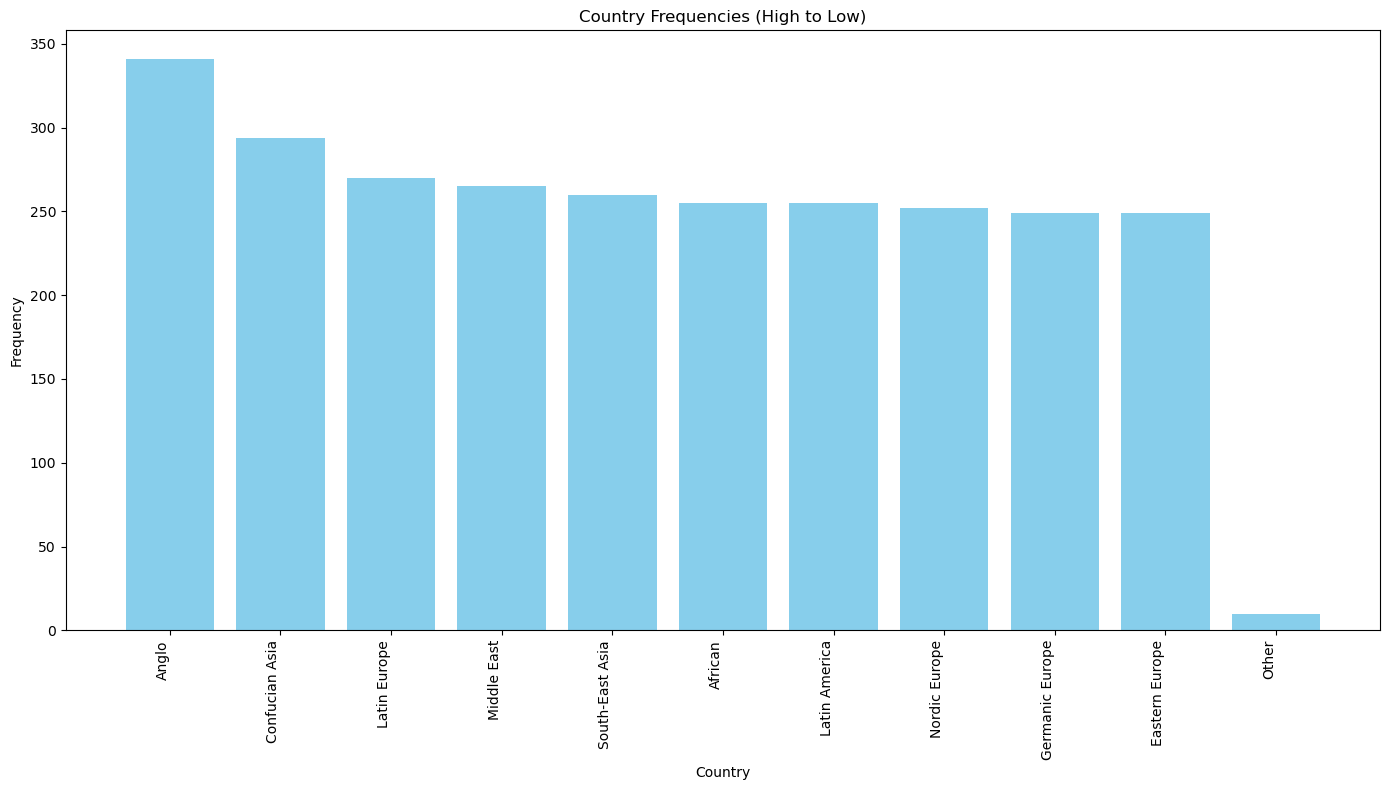

In [117]:
regions = defaultdict(int)
#print(countries)
for country in countries:
    regions[country_to_region_globe[country]]+=countries[country]
    
sorted_data = dict(sorted(regions.items(), key=lambda item: item[1], reverse=True))

print(sorted_data)
# Step 3: Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Frequencies (High to Low)")
plt.tight_layout()
plt.show()

In [118]:
import statistics
total = sum(sorted_data.values())

# Percentages
percentages = {k: (v / total) * 100 for k, v in sorted_data.items()}

# Mean and median
values = list(sorted_data.values())
mean_val = statistics.mean(values)
median_val = statistics.median(values)

# Print table
print(f"{'Region':20} {'Count':>6} {'Percent':>10}")
print("-" * 40)

for region, count in sorted(sorted_data.items(), key=lambda x: x[1], reverse=True):
    print(f"{region:20} {count:6d} {percentages[region]:9.2f}%")

print("\nSummary Statistics")
print("-" * 20)
print(f"Total samples: {total}")
print(f"Number of categories: {len(sorted_data)}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val}")

Region                Count    Percent
----------------------------------------
Anglo                   341     12.63%
Confucian Asia          294     10.89%
Latin Europe            270     10.00%
Middle East             265      9.81%
South-East Asia         260      9.63%
African                 255      9.44%
Latin America           255      9.44%
Nordic Europe           252      9.33%
Germanic Europe         249      9.22%
Eastern Europe          249      9.22%
Other                    10      0.37%

Summary Statistics
--------------------
Total samples: 2700
Number of categories: 11
Mean: 245.45
Median: 255


In [119]:
print(sorted_data)

{'Anglo': 341, 'Confucian Asia': 294, 'Latin Europe': 270, 'Middle East': 265, 'South-East Asia': 260, 'African': 255, 'Latin America': 255, 'Nordic Europe': 252, 'Germanic Europe': 249, 'Eastern Europe': 249, 'Other': 10}


In [120]:
import plotly.graph_objects as go

paises = list(countries.keys())
values = list(countries.values())

fig = go.Figure(go.Choropleth(
    locations=paises,
    locationmode='country names',
    z=values,
    text=[f"{c}: {v}" for c, v in zip(paises, values)],
    hovertemplate='<b>%{text}</b><extra></extra>',
    colorscale='Blues',
    colorbar=dict(title='Count', thickness=15, len=0.6),
    marker_line_color='white',
    marker_line_width=0.5,
))

fig.update_layout(
    title=dict(text='Country distribution', font_size=18, x=0.5, xanchor='center'),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgray',
        projection_type='natural earth',
        bgcolor='#f9f9f9',
        landcolor='#e8e8e2',
        showland=True,
    ),
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=60, b=0),
    height=520,
)

fig.show()
# To save as HTML instead:
# fig.write_html('world_map.html')

## DENSITY DISTRIBUTION BY GLOBE REGION (scattered / moderate / crowded)

Region               n       Scattered       Moderate        Crowded
Anglo              341      58 (17.0%)    112 (32.8%)    171 (50.1%)
Confucian Asia     294      75 (25.5%)     90 (30.6%)    129 (43.9%)
Latin Europe       270      53 (19.6%)     82 (30.4%)    135 (50.0%)
Middle East        265      61 (23.0%)     99 (37.4%)    105 (39.6%)
South-East Asia    260      60 (23.1%)     89 (34.2%)    111 (42.7%)
African            255      49 (19.2%)     94 (36.9%)    112 (43.9%)
Latin America      255      63 (24.7%)     90 (35.3%)    102 (40.0%)
Nordic Europe      252      86 (34.1%)     75 (29.8%)     91 (36.1%)
Eastern Europe     249      60 (24.1%)     78 (31.3%)    111 (44.6%)
Germanic Europe    249      33 (13.3%)     88 (35.3%)    128 (51.4%)
Other               10       2 (20.0%)      3 (30.0%)      5 (50.0%)


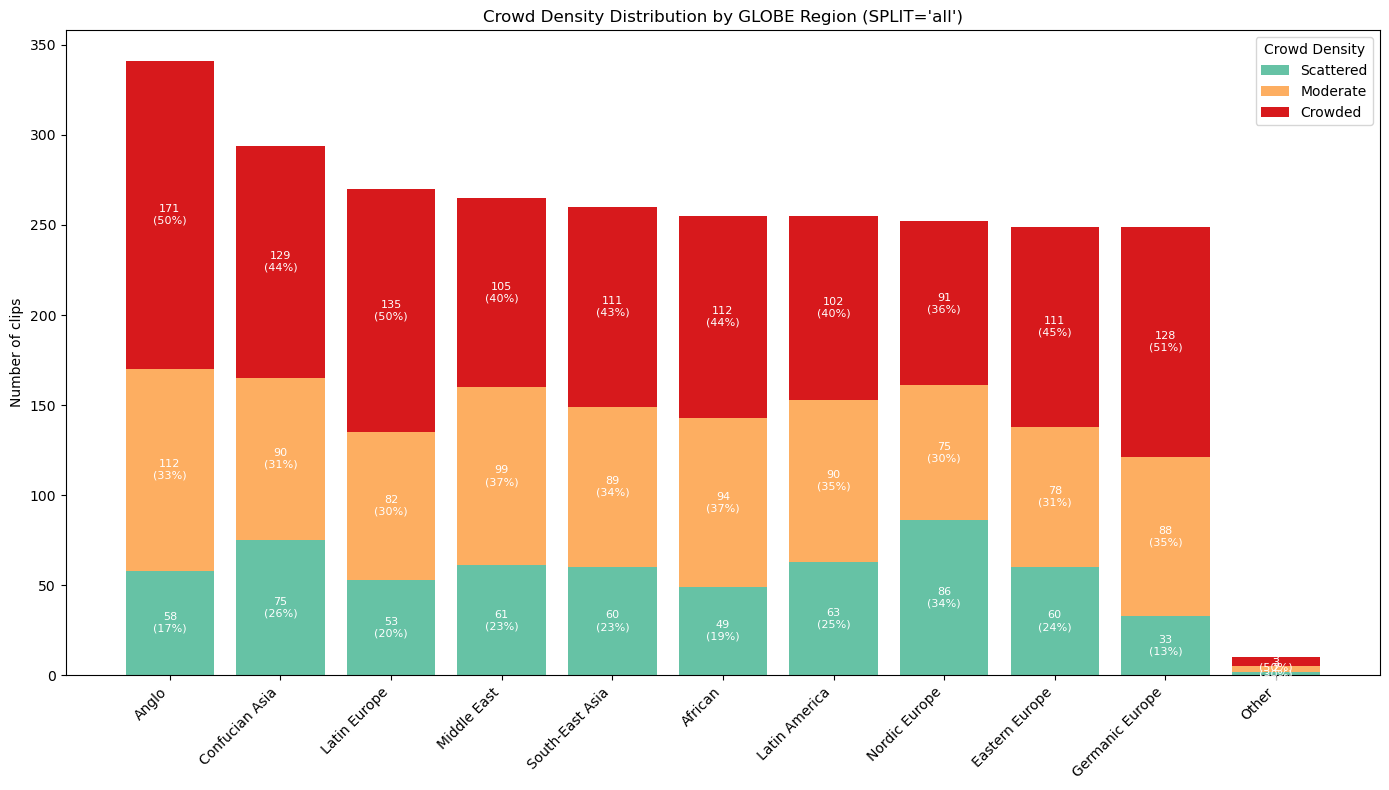

In [121]:
density_order = ['scattered', 'moderate', 'crowded']
density_colors = {'scattered': '#66c2a5', 'moderate': '#fdae61', 'crowded': '#d7191c'}

region_density = defaultdict(lambda: {d: 0 for d in density_order})

for file in files:
    with open(f'{file.replace("videos_frames", "jsons_step1")}.json', 'r') as f:
        data = json.load(f)
    region = data.get('globe_region', 'Other')
    density = data.get('density', 'unknown')
    if density not in region_density[region]:
        region_density[region][density] = 0
    region_density[region][density] += 1

region_order = sorted(region_density.keys(), key=lambda r: -sum(region_density[r].values()))


def cell_str(count, total):
    return f"{count:4d} ({100*count/total:4.1f}%)"


print(f"{'Region':16s} {'n':>5s}  {'Scattered':>14s} {'Moderate':>14s} {'Crowded':>14s}")
for r in region_order:
    counts = region_density[r]
    total = sum(counts.values())
    print(f"{r:16s} {total:5d}  {cell_str(counts['scattered'], total):>14s} "
          f"{cell_str(counts['moderate'], total):>14s} {cell_str(counts['crowded'], total):>14s}")

# Stacked bar chart with count + percentage labels on each segment
MIN_LABEL_FRAC = 0.05  # hide labels on segments too thin to read

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(region_order))
bottom = np.zeros(len(region_order))
totals = np.array([sum(region_density[r].values()) for r in region_order])

for density in density_order:
    values = np.array([region_density[r][density] for r in region_order])
    ax.bar(x, values, bottom=bottom, label=density.capitalize(), color=density_colors[density])
    for xi, (v, b, t) in enumerate(zip(values, bottom, totals)):
        if v / t >= MIN_LABEL_FRAC:
            ax.text(xi, b + v / 2, f"{v}\n({100*v/t:.0f}%)", ha='center', va='center',
                     color='white', fontsize=8)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(region_order, rotation=45, ha='right')
ax.set_ylabel('Number of clips')
ax.set_title(f'Crowd Density Distribution by GLOBE Region (SPLIT={SPLIT!r})')
ax.legend(title='Crowd Density')
plt.tight_layout()
plt.savefig('../results/density_dist_by_region.pdf', format='pdf', bbox_inches='tight')
plt.show()